IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME 5 : Validation croisée (fin), astuce du noyau, réduction de dimensionnalité: visualisation. 

<font size="+1" color="RED"><b>[Q]</b></font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

Alexandre Parant - Marc-Antoine Xia

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce fichier ipython**

Tout en haut de cette page, cliquer sur <tt>tme-05</tt> et rajouter à la suite de <tt>tme-05</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-05-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

/tmp/ipykernel_5270/1189054792.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Version python et des librairies:
	Python  3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
	pandas:  2.2.0
	numpy:  1.24.2
	matplotlib:  3.6.3


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
import sys
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev



# Bilan des séances précédentes

<div class="alert alert-block alert-warning">
Avant de commencer ce sujet, vous devez avoir terminé les TME précédents:

1. les fonctions pour générer des datasets uniformes, gaussiens et XOR, et pour les afficher.
2. les classifieurs: ClassifierKNN, ClassifierLineaireRandom, ClassifierPerceptronTME3, ClassifierPerceptron
3. le classifieur multiclasses ClassifierMultiOOA    
4. les fonctions de validation croisée: crossval, crossval_strat et analyse_perfs
5. toutes les fonctions et classes doivent avoir été testées et validées, et recopiées dans les fichiers correspondants:
    - utils.py pour les fonctions 1) 
    - Classifiers.py pour les fonctions 2) et 3) 
    - evaluations.py pour les fonctions 4)

Si vous n'avez pas terminé un de ces points, consacrez le début de ce TME 5 à vous mettre à jour.
</div>    

## Données pour tester

Pour expérimenter sur un petit dataset, on reprend les données du TME 3: faites un lien symbolique vers le sous-répertoire `data` (qui contient `data_train.csv` et `data_test.csv`) dans votre répertoire du TME 5.


Base d'apprentissage: (150, 2)	Base de test: (50, 2)


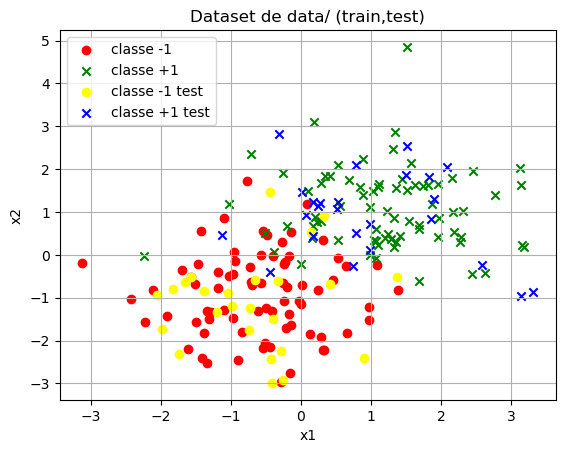

In [3]:
# Chargement des données qui se trouvent dans le répertoire data/
data = pd.read_csv("data/data_train.csv", header=None)
data_train = np.array(data[[0,1]])
label_train  = np.array(data[2])

data = pd.read_csv("data/data_test.csv", header=None)
data_test = np.array(data[[0,1]])
label_test  = np.array(data[2])

# Fusion de toutes les données:
data_all=np.concatenate((data_train,data_test))
label_all=np.concatenate((label_train,label_test))

print(f"Base d'apprentissage: {data_train.shape}\tBase de test: {data_test.shape}")
ut.plot2DTrainTestSet(data_train, label_train, data_test, label_test, nom_dataset="Dataset de data/ (train,test)")

## Une classe pour un perceptron stabilisé

Dans la structure des classes que l'on a choisi, le choix de l'apprentissage par stabilisation pour le perceptron se fait lors de l'appel de la méthode  `train` ou de la méthode `train_step`, cela ne sera pas pratique par la suite pour les fonctions de validation croisée ou du classifieur multiclasse car elles ne permettent pas d'appeler directement la méthode `train` avec le paramètre de stabilisation.

<font color="RED" size="+1"><b>[Q]</b></font> Ecrire une classe `ClassifierPerceptronStable` qui hérite de la classe `ClassifierPerceptron`. Cette classe ne redéfinit que la méthode `train`: celle-ci a exactement les mêmes arguments que la méthode `train` de la classe `ClassifierPerceptron` et elle se contente d'appeler la méthode `train` de sa classe mère en ajoutant aux arguments transmis l'argument `stabilised=True`.
On peut redéfinir aussi le constructeur pour afficher un message (par verbose) disant que c'est un perceptron stabilisé, même chose pour la méthode `__str__`.  


In [4]:
############################## A COMPLETER 
class ClassifierPerceptronStable(cl.ClassifierPerceptron):
    """ Perceptron de Rosenblatt stabilisé
    """
    def __init__(self, input_dimension, learning_rate=0.01, init=True,verbose=False):
        """ Constructeur de Classifier
            Argument:
                - input_dimension (int) : dimension de la description des exemples (>0)
                - learning_rate (par défaut 0.01): epsilon
                - init est le mode d'initialisation de w:
                    - si True (par défaut): initialisation à 0 de w,
                    - si False : initialisation par tirage aléatoire de valeurs petites
                - verbose: pour dire si on veut afficher la valeur d'initialisation
        """
        super().__init__(input_dimension, learning_rate, init,verbose)  # Appel du constructeur de la classe mère
        if verbose:
            print(f"{super().__str__()} (stabilise)")

    def __str__(self) -> str:
        """ rend une chaîne de caractères (méthode toString)
            Par exemple, pour afficher des informations sur l'objet
        """
        ################### A COMPLETER
        return super().__str__()

    
    def train(self, desc_set, label_set, nb_max=100, seuil=0.001,stabilised=True, verbose=False):
        """ Apprentissage itératif du perceptron sur le dataset donné.
            Arguments:
                - desc_set: array avec des descriptions
                - label_set: array avec les labels correspondants
                - nb_max (par défaut: 100) : nombre d'itérations maximale
                - seuil (par défaut: 0.01) : seuil de convergence
                - verbose (par défaut: False): affichage de messages d'information
            Retour: la fonction rend une liste
                - liste des valeurs de norme de différences
        """
        super().train(desc_set, label_set, nb_max, seuil,True, verbose)

### Vérification que la classe est bien définie
et qu'elle fournie le même résultat qu'un perceptron stabilisé.

#### Avec un perceptron stabilisé (version TME 4)

Classifier #1 (d2): initialisation (learning rate= 0.005) w= [-2.50919762e-04  9.01428613e-04  7.31993942e-01]
Apprentissage:
train  (2, 0.005, array([0.56415696, 0.75860377, 0.25381027])) : 42 appels à train_step
Accuracy Train:	0.9400
Accuracy Test:	0.8600


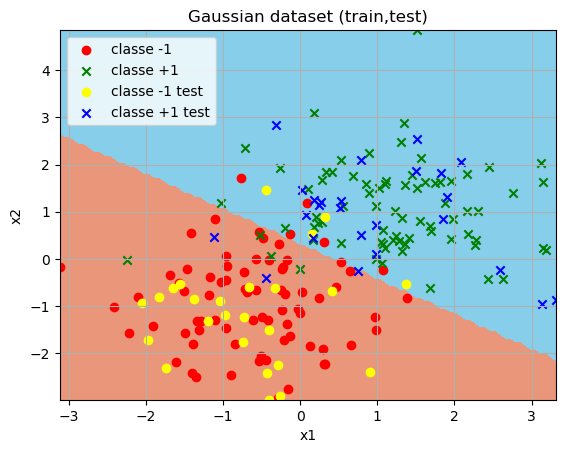

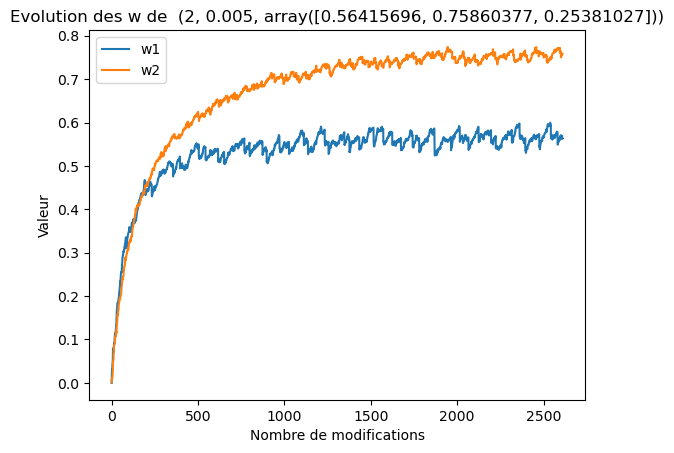

In [5]:
np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = 2
eps = 5e-3    # learning rate

# Création et entraînement d'un perceptron stabilisé avec la classe du TME 4
perceptron1 = cl.ClassifierPerceptron(dim, learning_rate=eps, init=False, verbose=True)
print("Apprentissage:")
perceptron1.train(data_train,label_train,nb_max=1000,stabilised=True,verbose=True)
print(f"Accuracy Train:\t{perceptron1.accuracy(data_train,label_train):1.4f}")
print(f"Accuracy Test:\t{perceptron1.accuracy(data_test,label_test):1.4f}")

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(data_all, label_all,perceptron1,step=100)
ut.plot2DTrainTestSet(data_train,label_train,data_test,label_test, nom_dataset="Gaussian dataset (train,test)")
# récupération de l'évolution des w au cours de l'apprentissage 

# si allw est sous forme de liste de couples [w1, w2], on doit la convertir en np.array pour la suite:
allw = np.array(perceptron1.get_allw()) 
# Tracé de l'évolution des w:
plt.figure()
plt.plot(allw[:,0]) # première coordonnée du vecteur poids: w1
plt.plot(allw[:,1]) # deuxième coordonnée du vecteur poids: w2
plt.title(f'Evolution des w de {perceptron1}')
plt.xlabel('Nombre de modifications')
plt.ylabel('Valeur')
plt.legend(['w1','w2'])


#### Avec la classe PerceptronStable

Classifier #2 (d2): initialisation (learning rate= 0.005) w= [-2.50919762e-04  9.01428613e-04  7.31993942e-01]
 (2, 0.005, array([-2.50919762e-04,  9.01428613e-04,  7.31993942e-01])) (stabilise)
Apprentissage:
train  (2, 0.005, array([0.56415696, 0.75860377, 0.25381027])) : 42 appels à train_step
Accuracy Train:	0.9400
Accuracy Test:	0.8600


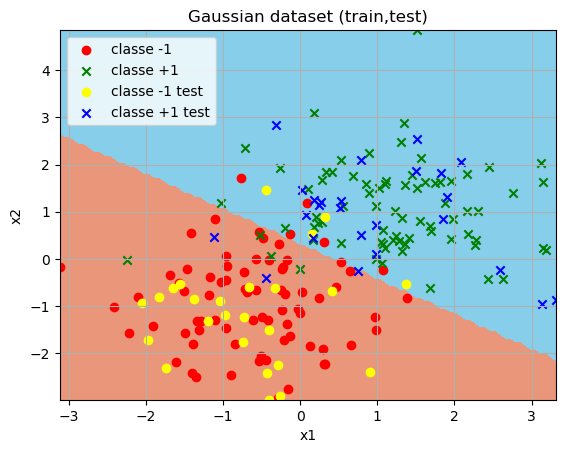

Le résultat doit être identique au précédent


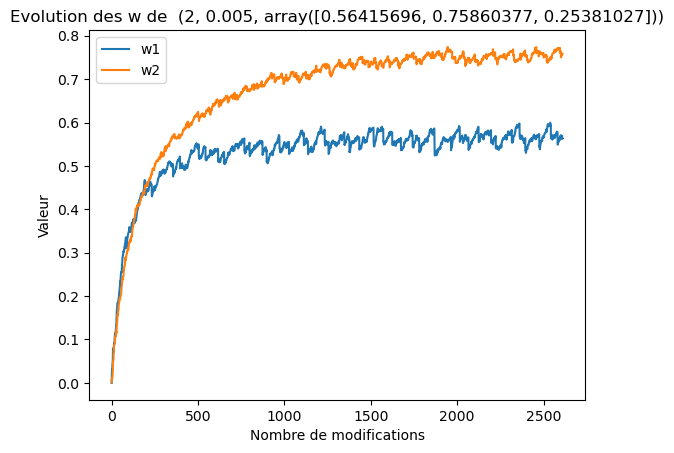

In [6]:
np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = 2
eps = 5e-3    # learning rate

# Création et entraînement d'un perceptron stabilisé avec la classe du TME 4
perceptron2 = ClassifierPerceptronStable(dim, learning_rate=eps, init=False, verbose=True)
print("Apprentissage:")
perceptron2.train(data_train,label_train,nb_max=1000,verbose=True)
print(f"Accuracy Train:\t{perceptron2.accuracy(data_train,label_train):1.4f}")
print(f"Accuracy Test:\t{perceptron2.accuracy(data_test,label_test):1.4f}")

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(data_all, label_all,perceptron2,step=100)
ut.plot2DTrainTestSet(data_train,label_train,data_test,label_test, nom_dataset="Gaussian dataset (train,test)")


# récupération de l'évolution des w au cours de l'apprentissage 
# si allw est sous forme de liste de couples [w1, w2], on doit la convertir en np.array pour la suite:
allw = np.array(perceptron2.get_allw()) 
# Tracé de l'évolution des w:
plt.figure()
plt.plot(allw[:,0]) # première coordonnée du vecteur poids: w1
plt.plot(allw[:,1]) # deuxième coordonnée du vecteur poids: w2
plt.title(f'Evolution des w de {perceptron2}')
plt.xlabel('Nombre de modifications')
plt.ylabel('Valeur')
plt.legend(['w1','w2'])

print("Le résultat doit être identique au précédent")

#### Copier la nouvelle classe dans `Classifier.py`

Si tout est ok, vous pouvez copier votre classe (en enlevant les `cl.`) dans votre librairie  `iads`.

## Une fonction pour la validation croisée

Reprendre le code écrit dans le TME 4 pour évaluer par validation croisée le perceptron stabilisé sur les données usps.

**Remarque**: penser à créer un lien symbolique vers le sous-répertoire `data` (qui contient `usps.pkl`) dans le répertoire de ce TME 4 (cf. séances précédentes).

In [7]:
# test sur les données USPS
import pickle as pkl

data = pkl.load(open('data/usps.pkl', 'rb'))
Xu = np.array(data['X_train'], dtype=float) # conversion de type pour une meilleure compatibilité
Yu = np.array(data['Y_train'], dtype=float)

# Création d'un sous groupe de données
c1 = 2  # ---> sera associée au label +1  
c2 = 6  # ---> sera associée au label -1
X12 = Xu[(Yu==c1) | (Yu==c2)]
Y12 = np.where(Yu[(Yu==c1) | (Yu==c2)]==c1, 1, -1)

np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = X12.shape[1]   # la dimension est donnée par le nombre de colonnes de X12
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

# Nombre d'itérations voulues pour la validation croisée:
nb_iter = 10
# Liste pour stocker les taux de bonne classification à chaque itération
perf = []

print("Validation croisée avec un perceptron stabilisé:")
print("Performances avec les classes ", c1," et ", c2)
# ######################## A COMPLETER CI-DESSOUS
# 1) mélanger des exemples 
index = np.random.permutation(len(X12)) # mélange des index
Xm = X12[index]
Ym = Y12[index]

# Paramètres pour le perceptron:
for i in range(nb_iter):
    Xapp,Yapp,Xtest,Ytest = ut.crossval(Xm, Ym, nb_iter, i)
    perceptron4 = cl.ClassifierPerceptronStable(dim, eps)
    perceptron4.train(Xapp, Yapp,stabilised=True)
    perf.append(perceptron4.accuracy(Xtest, Ytest))
# ######################## 
   
taux_moyen, taux_ecart = ev.analyse_perfs(perf)
print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')

Validation croisée avec un perceptron stabilisé:
Performances avec les classes  2  et  6
Analyse perf: moyenne: 0.9840	ecart: 0.0127


<font color="RED" size="+1"><b>[Q]</b></font> À partir de maintenant, on évaluera souvent les classifieurs en utilisant une validation croisée, pour faciliter cela, écrire la fonction `validation_croisee` qui prend en argument un classifieur déjà défini (mais pas entraîné), un tuple composé d'un dataset et de son ensemble de labels, et un entier naturel donnant le nombre d'itérations à réaliser. Cette fonction rend un triplet contenant la liste des performances obtenues, la performance moyenne et l'écart type.

Cette fonction doit réaliser le traitement que vous avez implémenté dans la boîte précédente et qui débute **après le mélange des exemples**, c'est-à-dire que cette fonction implémente l'étape 2) de la boîte précédente.


<font color="RED"><b>Attention !</b></font>: lors de la validation croisée, vous devrez dupliquer le classifieur afin qu'il soit ré-entrainé complètement depuis son état initial à chaque tour. Pour cela, vous utiliserez la commande `copy.deepcopy` qui permet d'obtenir une copie complète de l'objet classifieur.

In [8]:
import copy

def validation_croisee(C, DS, nb_iter, verbose = False):
    """ Classifieur * tuple[array, array] * int -> tuple[ list[float], float, float]
        Arguments:
            - C (Classifieur): un classifieur déjà défini (mais pas entraîné) 
            - DS (tuple[array,array]: un tuple composé d'un dataset (data, labels)
            - nb_iter (int): nombre d'itérations à réaliser
            - verbose: pour dire si on veut afficher des messages au cours de l'exécution
        Retour: tuple[ list[float], float, float]
            - triplet contenant la liste des performances obtenues, la performance moyenne et l'écart type
    """
    X12, Y12 = DS
    
    # 1) mélanger des exemples 
    index = np.random.permutation(len(X12)) # mélange des index
    Xm = X12[index]
    Ym = Y12[index]
    
    # Paramètres pour le perceptron:
    for i in range(nb_iter):
        Xapp,Yapp,Xtest,Ytest = ut.crossval(Xm, Ym, nb_iter, i)
        perceptron4 = copy.deepcopy(C)
        perceptron4.train(Xapp, Yapp,stabilised=True)
        perf.append(perceptron4.accuracy(Xtest, Ytest))

    taux_moyen, taux_ecart = ev.analyse_perfs(perf)
    if (verbose == True):
        print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')

    return perf, taux_moyen, taux_ecart
        
        


In [9]:
np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = X12.shape[1]   # la dimension est donnée par le nombre de colonnes de X12
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

# Nombre d'itérations voulues pour la validation croisée:
nb_iter = 10

print("Validation croisée avec un perceptron stabilisé:")
print("Performances avec les classes ",c1," et ", c2)

# Création du classifieur que l'on veut évaluer:
modele = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=poids_0,verbose=False)

# Remarque: ici, on ne mélange pas les exemples avant la validation croisée

# Evaluation du classifieur par validation croisée:
perf, taux_moyen, taux_ecart = validation_croisee(modele, (X12, Y12), nb_iter,verbose = True)

# ######################## 
print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')

Validation croisée avec un perceptron stabilisé:
Performances avec les classes  2  et  6
Analyse perf: moyenne: 0.9840	ecart: 0.0127
Analyse perf: moyenne: 0.9840	ecart: 0.0127


<div class="alert alert-block alert-success">

À partir d'ici, on considére que votre fonction  `validation_croisee` est opérationnelle et qu'elle a été ajoutée dans le fichier `evaluation.py` de la librairie `iads`.

</class>

### Validation croisée sur un classifieur multi-classes


<font color="RED" size="+1"><b>[Q]</b></font> Tester le classifieur multiclasse du TME 4, basé sur un classifieur perceptron biais, avec l'ensemble des données usps.


In [10]:
import time # pour chronométrer...

np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = Xu.shape[1]   # la dimension est donnée par le nombre de colonnes de Xu
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

# Nombre d'itérations voulues pour la validation croisée:
nb_iter = 3

print("Validation croisée avec un perceptron stabilisé:")
print("Performances avec toutes les classes (ATTENTION: cela peut être long !)")

## Mélange
index = np.random.permutation(len(Yu))
Xm = Xu[index]
Ym = Yu[index]

clb = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=poids_0,verbose=False)
modele = cl.ClassifierMultiOAA(dim, clb)

# Evaluation du classifieur par validation croisée:
tic = time.time()  # On lance le chrono
perf, taux_moyen, taux_ecart = ev.validation_croisee(modele, (Xu, Yu), nb_iter, verbose=True)
toc = time.time()  # On arrête le chrono

print(f'Temps passe: {(toc-tic):0.4f} secondes.')
print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')



Validation croisée avec un perceptron stabilisé:
Performances avec toutes les classes (ATTENTION: cela peut être long !)
Analyse perf: moyenne: 0.9306	ecart: 0.0068
Temps passe: 60.5072 secondes.
Analyse perf: moyenne: 0.9306	ecart: 0.0068


# Retour sur le XOR

Dans le TME 3, vous avez implémenté la fonction `create_XOR` qui permet de générer des données avec une distribution des classes très difficile à apprendre avec nos classifieurs linéaires.

Par exemple, on peut générer 400 exemples répartis équitablement en 2 classes.

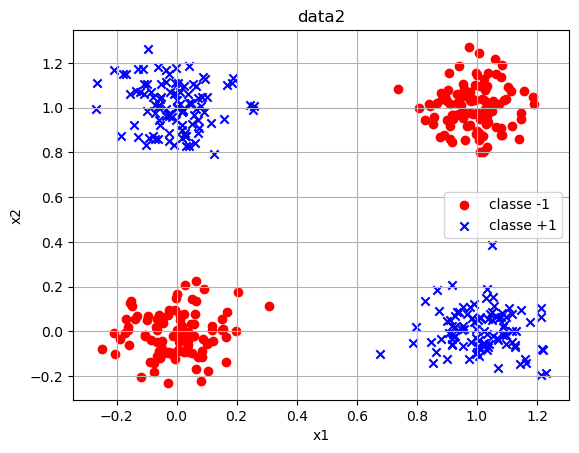

Nombre total d'exemples générés:  400
Nombre d'exemples de classe +1:  200
Nombre d'exemples de classe -1:  200


In [11]:
# Retour sur le XOR avec la fonction du TME 3 (mise dans votre librairie)

np.random.seed(42)   # on prend 42 comme graine

# Génération d'un dataset avec 400 exemples (100 par région du XOR):
data_xor, label_xor = ut.create_XOR(100,0.01)   # La fonction doit avoir été copiée dans utils.py
ut.plot2DSet(data_xor, label_xor)

print("Nombre total d'exemples générés: ",data_xor.shape[0])
print("Nombre d'exemples de classe +1: ",data_xor[label_xor==+1].shape[0])
print("Nombre d'exemples de classe -1: ",data_xor[label_xor==-1].shape[0])

In [12]:
np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = data_xor.shape[1]   # la dimension est donnée par le nombre de colonnes de X12
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

# Nombre d'itérations voulues pour la validation croisée:
nb_iter = 10

# Création du classifieur que l'on veut évaluer:
modele = cl.ClassifierPerceptronStable(dim, learning_rate=eps, init=poids_0,verbose=False)

# Remarque: on mélange les exemples avant la validation croisée
index = np.random.permutation(len(data_xor)) # mélange des index
data_xor_melange = data_xor[index]
label_xor_melange = label_xor[index]

# Evaluation du classifieur par validation croisée:
perf, taux_moyen, taux_ecart = ev.validation_croisee(modele, (data_xor_melange, label_xor_melange), nb_iter, verbose=True)

# ######################## 
print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')

Analyse perf: moyenne: 0.4400	ecart: 0.1085
Analyse perf: moyenne: 0.4400	ecart: 0.1085


Les résultats précédents ne sont vraiment pas très bons, le perceptron n'arrive pas à séparer correctement les 2 classes... (expliquer pourquoi)


## L'asture du noyau (*Kernel Trick*)

<div class="alert alert-block alert-info">

Comme vu en cours 4, l'**astuce du noyau ("kernel trick")** est un moyen pour améliorer ses performances.

Un **noyau** est une **fonction** (on parle de *fonction noyau*, *noyau* ou *kernel*) qui permet de représenter des données d'un espace donné dans un autre espace, souvent de dimension plus grande.

Par exemple, on considère une matrice en 2D d'observations:
$$X =\left[
    \begin{array}{cc}
    x_{11} & x_{12}\\
    \vdots & \vdots \\
    x_{N1} & x_{N2}\\
    \end{array}
    \right]\in \mathbb R^{N\times 2}$$

La fonction produite par un perceptron, $f(\mathbf x) = \mathbf w \cdot \mathbf x$, correspond à une frontière linéaire dans l'espace 2D... Qui passe par $(0,0)$ (sans biais).

Mais supposons que nous ajoutons des colonnes à $X$:
$$X^* =\left[
    \begin{array}{cccccc}
    x_{11} & x_{12} & x_{11}^2 & x_{12}^2 & x_{11} x_{12} & 1 \\
    \vdots & \ddots &&&&\vdots\\
    x_{N1} & x{N2} & x_{N1}^2 & x_{N2}^2 & x_{N1} x_{N2} & 1 \\
    \end{array}
    \right]\in \mathbb R^{N\times 6}$$

Les colonnes ajoutées sont obtenues à partir des colonnes initiales de $X$.

Maintenant, la fonction $f(\mathbf x^*) = \mathbf w \cdot \mathbf x^*$ correspond toujours à une frontière linéaire mais cette fois-ci dans un espace 6D... 
Mais sa projection dans l'espace 2D d'origine est une frontière non linéaire !


Un **noyau**  est donc une fonction de transformation
$$\begin{array}{cccc}
    K:& X & \rightarrow & X^*\\
      & \mathbf x & \mapsto &\mathbf x^*
\end{array}$$

</div>

**Note** Il faudra être très attentif, on fait tous les calculs avec des $\mathbf x^*$ mais on fait tous les affichages avec des $\mathbf x$...

Pour représenter des noyaux, on définit une classe abstraite `Kernel` qui sera étendue pour chaque noyau que l'on souhaitera créer.

In [13]:
# CLasse (abstraite) pour représenter des noyaux
class Kernel():
    """ Classe pour représenter des fonctions noyau
    """
    def __init__(self, dim_in, dim_out):
        """ Constructeur de Kernel
            Argument:
                - dim_in : dimension de l'espace de départ (entrée du noyau)
                - dim_out: dimension de l'espace de d'arrivée (sortie du noyau)
        """
        self.__input_dim = dim_in
        self.__output_dim = dim_out
        
    def get_input_dim(self):
        """ rend la dimension de l'espace de départ
        """
        return self.__input_dim

    def get_output_dim(self):
        """ rend la dimension de l'espace d'arrivée
        """
        return self.__output_dim
    
    def transform(self, V):
        """ ndarray -> ndarray
            fonction pour transformer V dans le nouvel espace de représentation
        """        
        pass


L'intérêt de définir une telle classe `Kernel` pour définir des noyaux est qu'elle permettra de définir des algorithmes de façon générique qui pourront alors prendre des noyaux quelconques en argument.

### Un premier noyau

Le premier noyau, très simple, que l'on définit permet de projeter (manuellement) des données 2D dans un espace de plus grande dimension. 

Voici un exemple de projection qui transforme le vecteur $(x_1,x_2)$ en vecteur $(x_1,x_2,1)$

In [14]:
class KernelBias(Kernel):
    """ Classe pour un noyau simple 2D -> 3D
    """
    def __init__(self):
        """ Constructeur de KernelBias
            pas d'argument, les dimensions sont figées
        """
        # Appel du constructeur de la classe mère
        super().__init__(2,3)
        
    def transform(self, V):
        """ ndarray de dim 2 -> ndarray de dim 3            
            rajoute une 3e dimension au vecteur donné
        """
        
        if (V.ndim == 1): # on regarde si c'est un vecteur ou une matrice
            W = np.array([V]) # conversion en matrice
            V_proj = np.append(W,np.ones((len(W),1)),axis=1)
            V_proj = V_proj[0]  # on rend quelque chose de la même dimension
        else:
            V_proj = np.append(V,np.ones((len(V),1)),axis=1)
            
        return V_proj
        

In [15]:
# Exemple d'utilisation : 
kb = KernelBias()

data_xor_bias= kb.transform(data_xor)

data_xor_bias

array([[ 1.04967142,  0.98617357,  1.        ],
       [ 1.06476885,  1.15230299,  1.        ],
       [ 0.97658466,  0.9765863 ,  1.        ],
       ...,
       [-0.10810565,  1.10531529,  1.        ],
       [-0.00395552,  1.06815007,  1.        ],
       [ 0.00283184,  1.00297561,  1.        ]])

### Un noyau un peu plus compliqué

<font color="RED" size="+1">**[Q]**</font> Définir la classe `KernelPoly` permettant de représenter le noyau : $(x_1,x_2) \mapsto (1,x_1,x_2,x_1*x_1,x_2*x_2,x_1*x_2)$. 

In [16]:
# ------------------------ A COMPLETER :

class KernelPoly(Kernel):
    def __init__(self):
        """ Constructeur de KernelPoly
            pas d'argument, les dimensions sont figées
        """
        # Appel du constructeur de la classe mère
        super().__init__(2,6)
        
    def transform(self,V):
        """ ndarray de dim 2 -> ndarray de dim 6            
            ...
        """
        colonne1Initial = np.array([V.T[0]]).T
        colonne2Initial = np.array([V.T[1]]).T

        res = np.array(V)
        res = np.append(res, np.array(colonne1Initial**2), axis=1)
        res = np.append(res, np.array(colonne2Initial**2), axis=1)
        res = np.append(res, np.array(colonne1Initial*colonne2Initial), axis=1)
        res = np.append(res, np.ones((V.shape[0], 1)), axis=1)
        
        return res

In [17]:
# Exemple d'utilisation 

kp = KernelPoly()

data_xor_poly = kp.transform(data_xor[0:4])

data_xor_poly


array([[1.04967142, 0.98617357, 1.10181008, 0.97253831, 1.03515821,
        1.        ],
       [1.06476885, 1.15230299, 1.13373271, 1.32780217, 1.22693633,
        1.        ],
       [0.97658466, 0.9765863 , 0.9537176 , 0.95372081, 0.95371921,
        1.        ],
       [1.15792128, 1.07674347, 1.34078169, 1.15937651, 1.24678418,
        1.        ]])

<font color="RED" size="+1">**[Q]**</font> Implémenter la classe `ClassifierPerceptronKernel` qui étend la classe `Classifier`. 
Pour définir cette classe possède les mêmes fonctionnalités que celles de la classe `ClassifierPerceptronTME3` (version TME 3 car on veut une version sans biais), en plus, elle prend en argument, lors de sa construction, un noyau (instance de la classe `Kernel`).
Une différence majeure avec le perceptron normal, et que le dataset fourni pour les méthodes `train_step` et `train`, ainsi que l'exemple donnée pour une prédiction, doit être *kernélisé* avant d'appliquer le traitement.

*Remarques :*
- le données sont donc kernélisée dans l'objet `ClassifierPerceptronKernel`.
- toutes les méthodes de la classe `ClassifierPerceptronTME3` ne sont pas nécessairement à réécrire dans `ClassifierPerceptronKernel`, seulement celles qui sont impactées par le changement apporté par l'utilisation du kernel.
 


In [18]:
# ------------------------ A COMPLETER :
class ClassifierPerceptronKernel(cl.ClassifierPerceptronTME3):
    """ Perceptron de Rosenblatt kernelisé
    """
    def __init__(self, input_dimension, learning_rate, noyau, init=True, verbose=False):
        """ Constructeur de Classifier
            Argument:
                - input_dimension (int) : dimension de la description des exemples (espace originel)
                - learning_rate : epsilon
                - noyau : Kernel à utiliser
                - init est le mode d'initialisation de w: 
                    - si True (par défaut): initialisation à 0 de w,
                    - si False : initialisation par tirage aléatoire de valeurs petites
                - verbose: pour dire si on veut afficher la valeur d'initialisation
        """
        super().__init__(input_dimension, learning_rate, init, verbose)
        
        self.kernel = noyau
        super().set_w( kp.transform( np.array([super().get_w()]))[0] )
        
        
    def train_step(self, desc_set, label_set):
        """ Réalise une unique itération sur tous les exemples du dataset
            donné en prenant les exemples aléatoirement.
            Arguments: (dans l'espace originel)
                - desc_set: ndarray avec des descriptions
                - label_set: ndarray avec les labels correspondants
        """   
        super().train_step(kp.transform(desc_set), label_set)

    def score(self,x):
        """ rend le score de prédiction sur x 
            x: une description (dans l'espace originel)
        """
        return super().score(x)

    def predict(self, x):
        """ rend la prediction sur x (soit -1 ou soit +1)
            x: une description
        """
        xs = kp.transform( np.array([x]))[0]
        score = self.score(xs)
        return 1 if self.score(xs) > 0 else -1
    


<font color="RED" size="+1">**[Q]**</font> Entraîner un perceptron kernelisé utilisant un `KernelPoly` sur un dataset correspondant au XOR. Que constate-t-on ? Expliquer.

Nb iterations:  19


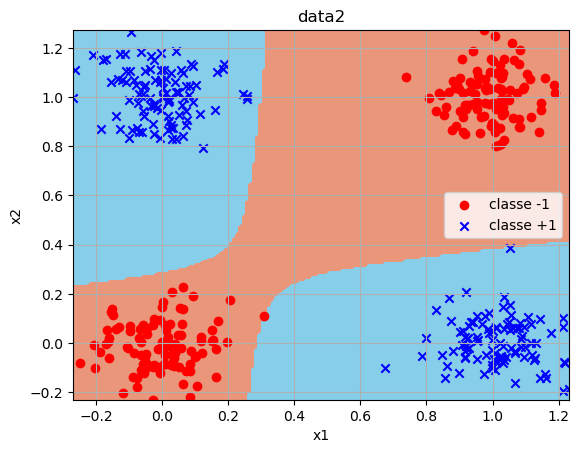

Accuracy finale :  1.0


In [19]:
# Pour avoir les mêmes valeurs aléatoires :
np.random.seed(42)   # supprimer cette ligne une fois la mise au point terminée

# Paramètres pour le perceptron:
dim = data_xor.shape[1]   # la dimension est donnée par le nombre de colonnes de X12
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

##################################################    
# ------------------------ A COMPLETER :

perceptron_kernel = ClassifierPerceptronKernel(dim, eps, KernelPoly(), poids_0, False )

##################################################    
# Pour mémoriser les différence:
les_variations = perceptron_kernel.train(data_xor, label_xor)
print("Nb iterations: ",len(les_variations))

# Affichage de la frontière de séparation des classes
ut.plot_frontiere(data_xor, label_xor,perceptron_kernel,step=150)
ut.plot2DSet(data_xor, label_xor)

print("Accuracy finale : ", perceptron_kernel.accuracy(data_xor, label_xor))

On peut évaluer les résultats d'une validation croisée avec ce kernel.

In [21]:
np.random.seed(42)   # on prend 42 comme graine

# Paramètres pour le perceptron:
dim = data_xor.shape[1]   # la dimension est donnée par le nombre de colonnes de X12
eps = 1e-3    # learning rate
poids_0 = True   # valeur initiale des poids à 0

# Nombre d'itérations voulues pour la validation croisée:
nb_iter = 10

##################################################    
# ------------------------ A COMPLETER :

modele = ClassifierPerceptronKernel(dim, eps, KernelPoly(), poids_0, False )

##################################################    
# Remarque: on mélange les exemples avant la validation croisée
index = np.random.permutation(len(data_xor)) # mélange des index
data_xor_melange = data_xor[index]
label_xor_melange = label_xor[index]

# Evaluation du classifieur par validation croisée:
perf, taux_moyen, taux_ecart = ev.validation_croisee(modele, (data_xor, label_xor), nb_iter,verbose=True)

# ######################## 
print(f'Analyse perf: moyenne: {taux_moyen:0.4f}\tecart: {taux_ecart:0.4f}')

Analyse perf: moyenne: 0.9950	ecart: 0.0100
Analyse perf: moyenne: 0.9950	ecart: 0.0100


# Visualisation de données

Dans cette partie, on réalise une série d'expériences pour appréhender la visualisation de données et la réduction de la dimensionnalité:

1. Comprendre la signification des valeurs propres et vecteurs propres sur les données gaussiennes sur lesquelles nous avons travaillé jusqu'ici
1. Générer un jeu de données jouet en 3D puis réduire la dimensionnalité
1. Appliquer cette réduction de dimension sur les données USPS

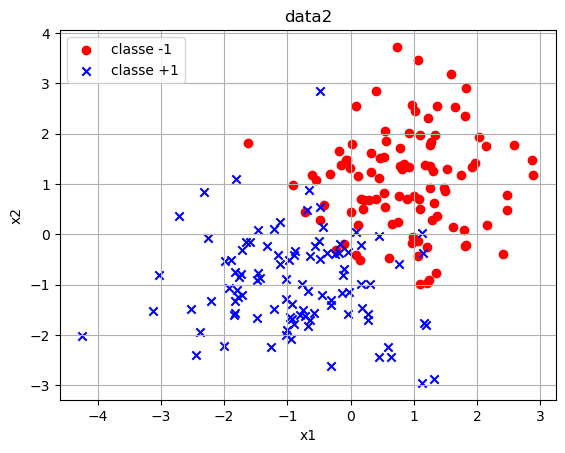

In [31]:
# Exemple d'utilisation:
np.random.seed(42)   # on prend 42 comme graine

# générer des données gaussienne 2D

N = 100
X,Y =  ut.genere_dataset_gaussian([-1,-1],[[1,0],[0,1]], [1, 1],[[1,0],[0,1]],N)

ut.plot2DSet(X,Y)

<font color="RED" size="+1"><b>[Q]</b></font> Avant de poursuivre, répondez aux questions suivantes:
- Combien y a-t-il de vecteurs propres et de valeurs propres dans ce problème?
- Quel axe de plus forte variance est pressenti?

Réponses:


2 vecteurs propres
et 2 valeurs propres


<font color="RED" size="+1"><b>[Q]</b></font> Donner les instructions pour récupérer les valeurs propres et vecteurs propres de la 
matrice X, puis les afficher.

Aide: voir la fonction `np.linalg.eig` (https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)

In [53]:
# Décommentez et compléter la ligne suivante: 
ValP, VectP = np.linalg.eig(np.cov(X.T) * (X.shape[0]-1)) 

# ###################################

print("1er valeur rendue:\n", ValP)
print("2e valeur rendue :\n", VectP)

1er valeur rendue:
 [187.30857353 529.88247229]
2e valeur rendue :
 [[-0.75656539 -0.65391804]
 [ 0.65391804 -0.75656539]]


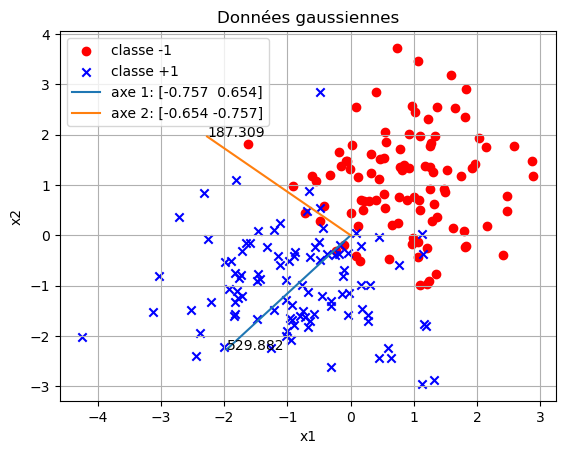

In [100]:
# tracer les vecteurs propres, à partir de (0,0) sur le scatter des points (X,Y)
# A l'aide de la commande plt.text, vous pouvez rajouter la "force" des axes si vous voulez

plt.figure()
plt.grid('on')
# Affichage de l'ensemble des exemples :
plt.scatter(X[Y==-1,0],X[Y==-1,1],marker='o', color="red", label='classe -1') # 'o' rouge pour la classe -1
plt.scatter(X[Y==1,0],X[Y==1,1],marker='x', color="blue", label='classe +1') # 'x' bleu pour la classe +1
# Informations d'affichage :
plt.title('Données gaussiennes')    
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)  

# ###################################
plt.plot(np.array([0, VectP[0][1]*3]), np.array([0, VectP[0][0]*3]))
plt.plot(np.array([0, VectP[1][1]*3]), np.array([0, VectP[1][0]*3]))

plt.text(VectP[0][1]*3, VectP[0][0]*3, np.round(ValP[1],3))
plt.text(VectP[1][1]*3, VectP[1][0]*3, np.round(ValP[0],3))
    
# ###################################

# Affichage de la légende!
plt.legend(["classe -1", "classe +1",f"axe 1: {np.round(VectP[:,0],3)}",f"axe 2: {np.round(VectP[:,1],3)}"])


# Si vous voulez sauvegarder l'image : 
#plt.savefig("out/acp.png",bbox_inches='tight', transparent=True,pad_inches=0)

plt.show()

On voit bien la principale direction de variance (associée à la plus grande valeur propre)

## Réduction de données 2D => 1D

Dans une logique de réduction de dimensionnalité, on souhaite:
1. extraire automatiquement le vecteur propre associé à la plus grande valeur propre
1. projeter les données sur cet axe
1. afficher le plot 1D des données suivant:
    - x = nouvelle coordonée (unique) du point
    - y = étiquette

Cet affichage va nous permettre de comprendre ce que nous venons de faire.

<font color="RED" size="+1"><b>[Q]</b></font> Donner les instructions qui réalisent les 3 étapes données ci-dessus.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


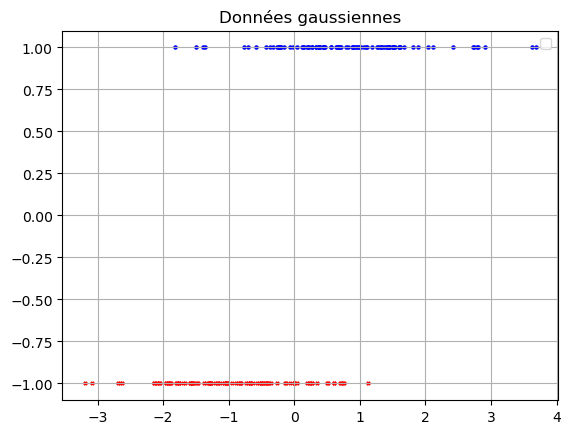

In [129]:
import math

plt.figure()

# ###################################
vproj = VectP[np.argmax(ValP)]
proj = np.dot(X, vproj)

# ###################################
plt.scatter(proj[Y==1] + vproj[0], Y[Y==1], marker='o', color="blue", s=5)
plt.scatter(proj[Y==-1] + vproj[1], Y[Y==-1], marker='x', color="red", s=5)
plt.title('Données gaussiennes')    
plt.legend()
plt.grid(True)  # Grille: à mettre, ou pas

#plt.savefig("out/proj_1D.png",bbox_inches='tight', transparent=True,pad_inches=0)


Vous devez obtenir:

(si l'image ne s'affiche pas, aller la voir dans le répertoire `ressources/`, c'est l'image `proj_1D.png`.

<table border="0">
 <tr>
    <td><img src="ressources/proj_1D.png" width=300px></td>
    <td>L'axe de plus forte variance semble bien intéressant pour distinguer les deux classes de données</td>
 </tr>
</table>

Pour mieux comprendre ce qui se passe, je vous propose la figure explicative suivante qui illustre ce que vous avez fait du point de vue géométrique:
<img src="ressources/proj_2D.png" width=300px>


(si l'image ne s'affiche pas, aller la voir dans le répertoire `ressources/`, c'est l'image `proj_2D.png`.

**Note:** cette dernière figure est non-triviale à obtenir, il ne faut pas perdre du temps en TP à chercher comment faire :)

## Réduction de données d-D => 2D

Passons maintenant sur les données USPS pour essayer de reproduire les figures du cours 5.

In [130]:
# On recharge les données USPS :
data = pkl.load(open('data/usps.pkl', 'rb'))
Xu = np.array(data['X_train'], dtype=float) # conversion de type pour une meilleure compatibilité
Yu = np.array(data['Y_train'], dtype=float)
XTu = np.array(data['X_test'], dtype=float) # conversion de type pour une meilleure compatibilité
YTu = np.array(data['Y_test'], dtype=float)


<font color="RED" size="+1"><b>[Q]</b></font> Donner les instructions qui réalisent les 3 étapes suivantes:

1. Extraire automatiquement les 2 vecteurs propres associés aux 2 plus grandes valeurs propres sur les données USPS
1. Projeter les données sur ces axes
    - projeter toutes les données
    - projeter seulement les 200 premières images (pour mieux voir)
1. Afficher avec un code couleur correspondant aux classes

Cet affichage va nous permettre de comprendre ce que nous venons de faire.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


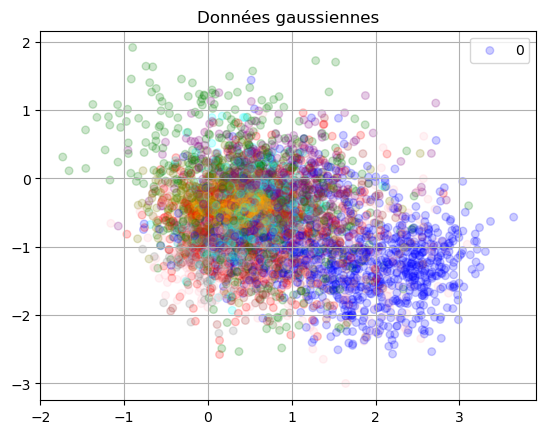

In [168]:
# A réaliser :
import matplotlib.colors as mcolors

# 1) calcul des vecteurs propres
Xc = X - np.mean(X, axis=0)
Cov = np.cov(Xc.T)
ValP, VectP = np.linalg.eig(Cov) 

# 2) affichage (print)
#print(VectP)

# 3) tri et sélection des 2 vecteurs associés aux 2 plus grandes valeurs propres 
idx = np.argsort(ValP)[::-1]
vproj = VectP[:, idx[:2]] 
X_proj = np.dot(Xc, vproj)

colors = ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray", "olive", "cyan"]
clist = [colors[int(i)] for i in Y]

# 4) affichage (plot) avec un code couleur pour les classes
plt.figure()
plt.scatter(X_proj[:, 0], X_proj[:, 1], c=clist, marker="o", s=30, alpha=0.2)
plt.title('Données gaussiennes')    
plt.legend()
plt.grid(True)  # Grille: à mettre, ou pas
plt.legend(np.arange(10))
#plt.show()

#plt.savefig("out/proj_usps_all.png",bbox_inches='tight', transparent=True,pad_inches=0)



Vous devez obtenir:
<table border="0">
 <tr>
    <td><img src="ressources/proj_usps_all.png"></td>
 </tr>
</table>

(si l'image ne s'affiche pas, aller la voir dans le répertoire `ressources/`, c'est l'image `proj_usps_all.png`.

On a l'impression que les 0 et 1 sont bien séparés des autres classes... Le reste est un peu confus mais on voit que:
- les 8 et les 9 se ressemblent
- les 6 et les 3 dans une moindre mesure
- les 7 et les 4 un peu aussi
- les 2 sont en plein milieu

## Interprétation des vecteurs propres

Chacun de nos 2 axes contient beaucoup d'informations... Mais lesquelles?
Ces axes sont en 256 dimensions, il est possible de les tracer comme une image. L'idée est de distinguer les dimensions positives et les dimensions négatives.
On ne va pas reconstruire une échelle de couleur propre... Mais on peut a minima afficher l'échelle.

Le code est fourni ci-dessous.

<table border="0">
 <tr>
    <td><img src="ressources/vp_0.png"></td>
    <td><img src="ressources/vp_1.png"></td>
 </tr>
</table>

Le premier axe est sensible aux pixels allumés en haut et en bas: sur le premier axe de la figure de la boite précédente, on remarque que les chiffres les plus à droite sont le 0 et le 3... Ca colle.

Le second axe est sensible aux pixels à gauche et à droite (en positif) et aux pixels du centre (en négatif). On a bien les 0 en haut et les 1 en bas de ce second axe.

In [173]:
for i in range(VectP.shape[1]):
    plt.figure()
    plt.imshow(VectP[:,i].reshape(16,16),cmap='bwr')
    plt.colorbar()
    #plt.savefig("out/vp_"+str(i)+".png",bbox_inches='tight', transparent=True,pad_inches=0)
    #plt.show()

IndexError: tuple index out of range

## Vers un espace de représentation débruité

Que se passe-t-il si on classe les points dans cet espace?
En 2d, on voit qu'il n'y a pas assez de dimension... Mais on peut:

1. Etudier les valeurs de toutes les valeurs propres (triées) pour voir combien sont importantes
    - soit on trie et on affiche les valeurs
    - soit on trace un histogramme des valeurs
1. Choisir un nombre de vecteurs propres par rapport à l'expérience précédente... On se rend compte que ce n'est pas évident: peu de valeurs propres captent toute l'énergie. En tout état de cause, 20 valeurs propres semblent raisonnables
1. Projeter les données d'apprentissage et de test
1. Etudier le taux de bonne classification dans ce nouvel espace par rapport à l'espace d'origine

(array([195.,  18.,  12.,   6.,   3.,   4.,   2.,   2.,   1.,   1.,   0.,
          2.,   0.,   1.,   1.,   0.,   1.,   1.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([3.84322081e+00, 1.38188513e+03, 2.75992703e+03, 4.13796893e+03,
        5.51601084e+03, 6.89405274e+03, 8.27209465e+03, 9.65013655e+03,
        1.10281785e+04, 1.24062204e+04, 1.37842623e+04, 1.51623042e+04,
        1.65403461e+04, 1.79183880e+04, 1.92964299e+04, 2.06744718e+04,
        2.20525137e+04, 2.3430

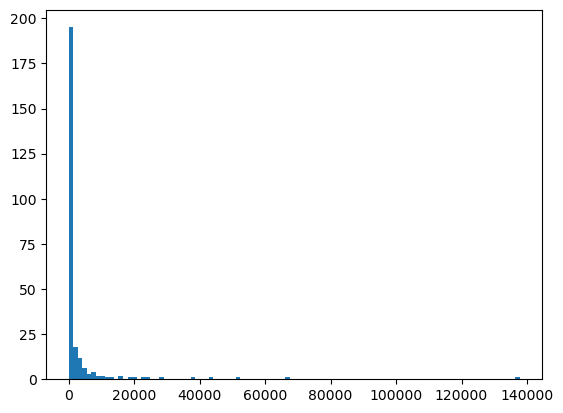

In [179]:
# Etude des valeurs propres
plt.figure()

# Regarder les 2 types d'affichage en commentant/décommentant l'un après l'autre:

# Affichage d'un histogramme: (Essayez différentes tailles d'histogramme)
plt.hist(ValP, 100)

# Affichage des valeurs :
#plt.plot(ValP)
#plt.show()


## Apprentissage après réduction des dimensions

In [181]:
# réduction à 20 dimensions
ndim = 20
Xr = Xu @ VectP[:,:ndim]
XTr = XTu @ VectP[:,:ndim]

# Exemple d'utilisation:
np.random.seed(42)   # on prend 42 comme graine

# Apprentissage d'un perceptron multiclasses

modele_reduit = cl.ClassifierPerceptronStable(input_dimension=ndim, learning_rate=1e-3, init=True, verbose=True)
clmulti_reduit = cl.ClassifierMultiOAA(20, modele_reduit)

tic = time.time()  # On lance le chrono
clmulti_reduit.train(Xr, Yu)
toc = time.time()  # On arrête le chrono

perf_A = clmulti_reduit.accuracy(Xr, Yu)
perf_T = clmulti_reduit.accuracy(XTr, YTu)

print(f"\nTaux de bonne classification : Train: {perf_A:.4}, Test: {perf_T:.4}, en {toc-tic:0.4} secondes")


Classifier #20 (d20): initialisation (learning rate= 0.001) w= [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 (20, 0.001, array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])) (stabilise)

Taux de bonne classification : Train: 0.9112, Test: 0.8993, en 28.84 secondes
